# RF 03 — Training Model

Run the complete candidate workflow. The runner fits the selected Random Forest configuration separately for every horizon and validation fold.

In [2]:
# Import libraries
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Define the root directory of the project and config file
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "random_forest_regressor.yaml"
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/Codigo/ontario-electricity-peak-risk/configs/random_forest_regressor.yaml')

Training is performed only on the shared development folds. The final 2025 holdout remains protected.

In [4]:
# Import functions to run Randon Forest model
from src.ontario_peak_risk.models.forecasting.random_forest.run_model import run_random_forest_regressor

In [5]:
# Run the model - Random Forest Regressor
results = run_random_forest_regressor(CONFIG_PATH)


Random Forest Regressor completed successfully.
Best parameters: {'n_estimators': 160, 'max_depth': None, 'min_samples_leaf': 5, 'max_features': 0.7}
Final 2025 holdout evaluated: NO


In [6]:
# Display results
results["fold_metrics"]

,fold,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,572.528742,992.601329,5.735863,6.344097,-185.472987,1257984
1,fold_2024,512.064401,854.826609,5.369000,5.581949,-65.316194,1261440


### Hyperparameter Tuning

Review the moderate tuning experiment and selected parameter set.

In [7]:
# Display tuning summary
results["tuning_summary"]

,parameter_id,n_estimators,max_depth,min_samples_leaf,max_features,mean_mae,mean_rmse,mean_mape
0,4,160,NaN,5,0.7,528.722937,898.014553,5.411028
1,3,160,16.0,3,0.7,535.896081,905.367347,5.499350
2,2,120,20.0,1,sqrt,546.825245,940.928809,5.490049
3,1,120,12.0,1,sqrt,573.304951,962.376879,5.861284


In [8]:
# Display best parameters
results["best_parameters"]

{'n_estimators': 160,
 'max_depth': None,
 'min_samples_leaf': 5,
 'max_features': 0.7}

### Evaluation

Review common metrics and visualize Actual vs Predicted performance.

In [9]:
# Display Global metrics
results["global_metrics"]

,model,mae,rmse,mape,wape,bias,n_observations
0,random_forest_regressor,542.255101,926.184858,5.55218,5.95938,-125.312178,2519424


In [10]:
# Display Flod Metrics 
results["fold_metrics"]

,fold,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,572.528742,992.601329,5.735863,6.344097,-185.472987,1257984
1,fold_2024,512.064401,854.826609,5.369000,5.581949,-65.316194,1261440


In [13]:
# Display FSA metrics
results["fsa_metrics"]


,fold,fsa,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,L4T,630.171143,1031.895478,5.168029,5.574038,-35.771671,209664
1,fold_2023,M5R,428.938568,609.338122,5.621392,5.758046,42.958778,209664
2,fold_2023,M5S,196.404645,271.400489,4.839064,4.926207,20.939367,209664
3,fold_2023,M6G,625.056517,933.555268,5.157068,5.386810,-172.609542,209664
4,fold_2023,M9R,365.883324,615.735584,6.098635,6.600703,5.068780,209664
5,fold_2023,M9W,1188.718257,1775.142021,7.530991,8.336498,-973.423632,209664
6,fold_2024,L4T,672.509925,1079.570503,5.382505,5.781708,-96.997473,210240
7,fold_2024,M5R,421.225256,600.525833,5.526707,5.612136,13.918655,210240
8,fold_2024,M5S,196.400400,274.004658,4.863930,4.909417,18.822284,210240
9,fold_2024,M6G,635.727293,933.919086,5.311313,5.439897,-94.622768,210240


In [14]:
# Display Horizon Metrics
results["horizon_metrics"]

,fold,horizon,target,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,1,target_h01,511.782477,924.245340,4.863689,5.671710,-313.092278,52416
1,fold_2023,2,target_h02,532.584878,963.780600,5.036174,5.902198,-320.968844,52416
2,fold_2023,3,target_h03,518.723271,921.999035,4.998489,5.748541,-283.410941,52416
3,fold_2023,4,target_h04,512.429200,895.738558,5.021800,5.678752,-248.669798,52416
4,fold_2023,5,target_h05,507.892742,873.553462,5.048499,5.628437,-215.499726,52416
5,fold_2023,6,target_h06,525.459690,907.349158,5.214523,5.823064,-213.035746,52416
6,fold_2023,7,target_h07,535.978081,927.582513,5.342120,5.939572,-198.319470,52416
7,fold_2023,8,target_h08,548.686733,949.378874,5.474250,6.080346,-191.713061,52416
8,fold_2023,9,target_h09,563.904624,982.082134,5.618653,6.248909,-190.698064,52416
9,fold_2023,10,target_h10,576.072442,1003.215752,5.738789,6.383652,-189.355116,52416


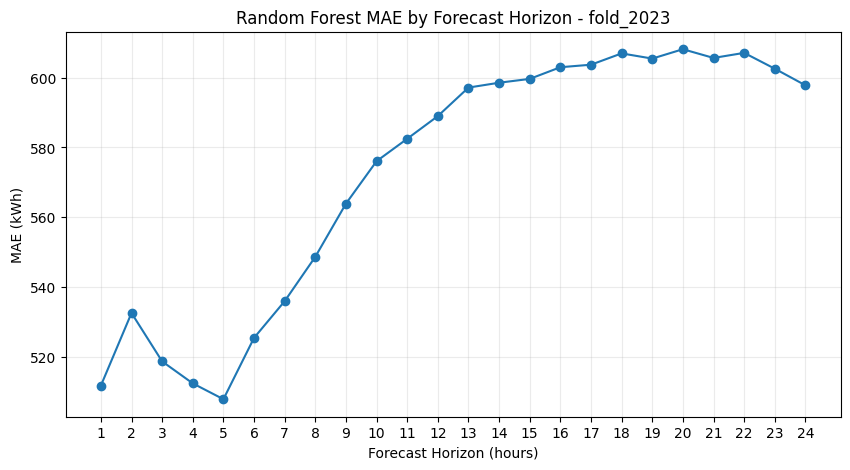

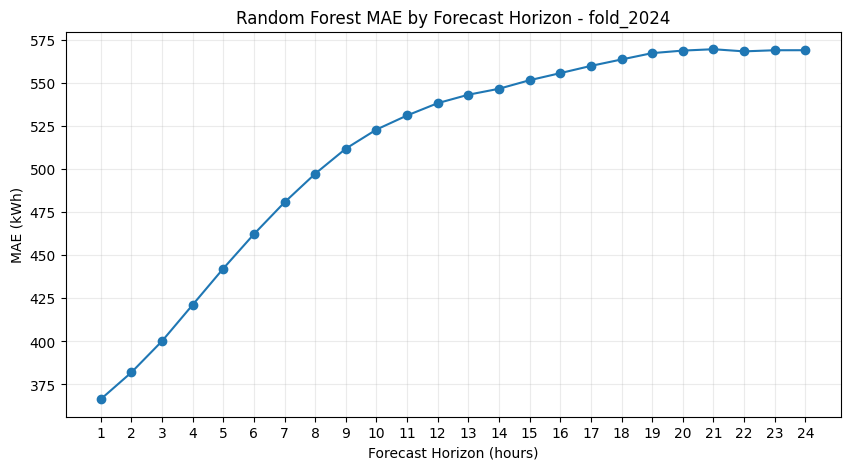

In [15]:
# MAE by forecast horizon
for fold, group in results["horizon_metrics"].groupby("fold"):
    plt.figure(figsize=(10, 5))
    plt.plot(group["horizon"], group["mae"], marker="o")
    plt.xlabel("Forecast Horizon (hours)")
    plt.ylabel("MAE (kWh)")
    plt.title(f"Random Forest MAE by Forecast Horizon - {fold}")
    plt.xticks(range(1, 25))
    plt.grid(alpha=0.25)
    plt.show()

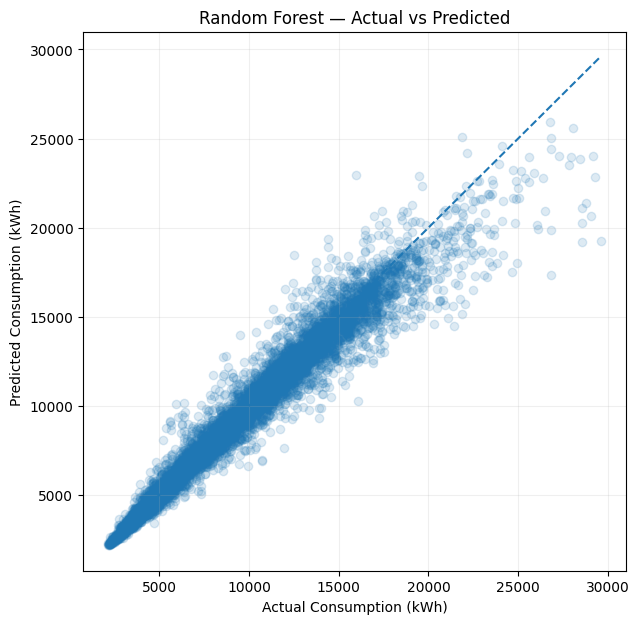

In [16]:
# Actual vs Predicted scatter plot
sample = results["predictions"].sample(
    n=min(10000, len(results["predictions"])),
    random_state=42,
)

plt.figure(figsize=(7, 7))
plt.scatter(sample["actual"], sample["predicted"], alpha=0.15)

minimum = min(sample["actual"].min(), sample["predicted"].min())
maximum = max(sample["actual"].max(), sample["predicted"].max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")

plt.xlabel("Actual Consumption (kWh)")
plt.ylabel("Predicted Consumption (kWh)")
plt.title("Random Forest — Actual vs Predicted")
plt.grid(alpha=0.2)
plt.show()

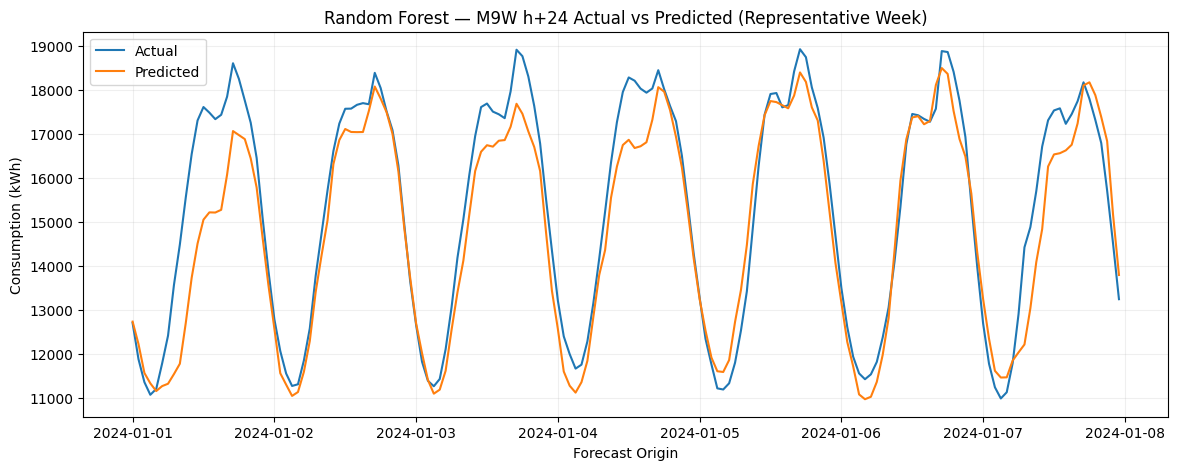

In [17]:
# Representative 7-day time-series comparison
plot_data = (
    results["predictions"]
    .query("fold == 'fold_2024' and fsa == 'M9W' and horizon == 24")
    .sort_values("forecast_origin")
    .head(24 * 7)
)

plt.figure(figsize=(14, 5))
plt.plot(plot_data["forecast_origin"], plot_data["actual"], label="Actual")
plt.plot(plot_data["forecast_origin"], plot_data["predicted"], label="Predicted")
plt.xlabel("Forecast Origin")
plt.ylabel("Consumption (kWh)")
plt.title("Random Forest — M9W h+24 Actual vs Predicted (Representative Week)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Interpretation

Inspect the variables most frequently used by the fitted forests.

In [18]:
# Display Feature importance
importance = results["feature_importance"].head(15)
importance

,feature,importance
0,target_lag_24h,0.690883
1,target_lag_48h,0.172395
2,target_lag_168h,0.075846
3,origin_rolling_mean_24h,0.015773
4,origin__Temp (°C),0.011859
5,origin_rolling_std_24h,0.005081
6,origin_rolling_mean_168h,0.004402
7,origin__reported_premise_count,0.003769
8,origin__Stn Press (kPa),0.003360
9,origin__Rel Hum (%),0.002257


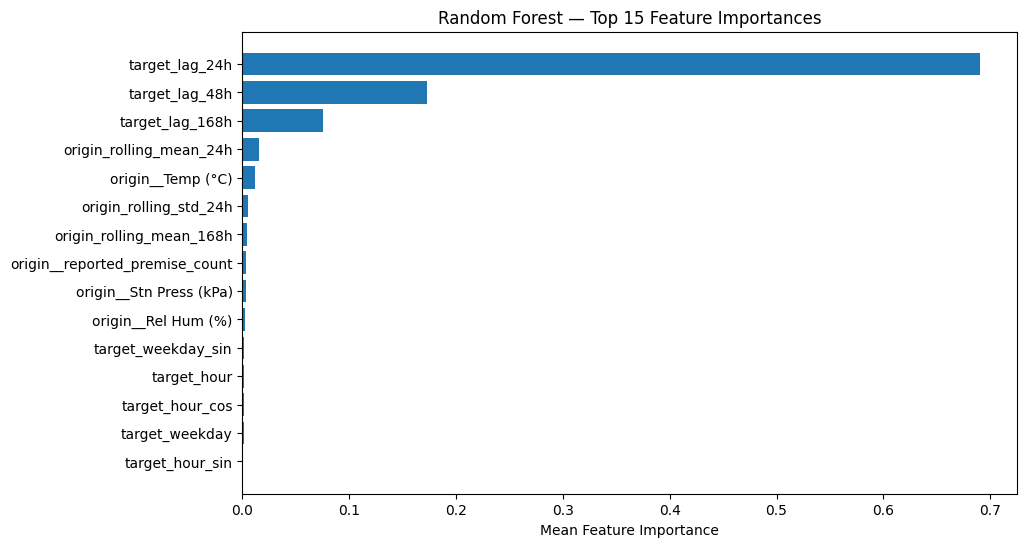

In [19]:
# Plot Feature importance
plt.figure(figsize=(10, 6))
plot_data = importance.sort_values("importance")
plt.barh(plot_data["feature"], plot_data["importance"])
plt.xlabel("Mean Feature Importance")
plt.title("Random Forest — Top 15 Feature Importances")
plt.show()